In [1]:
# Run this cell if you're using from colab
#!git clone https://github.com/R-Oc-A/HackathonPastryLPV.git
#!wget https://github.com/R-Oc-A/HackathonPastryLPV/releases/download/IntensityGrids/grids.tar.gz
#!wget https://github.com/R-Oc-A/HackathonPastryLPV/releases/download/IntensityGrids/famias.tar.gz
#!tar -xvf grids.tar.gz
#!tar -xvf famias_grids.tar.gz
#!pip install https://github.com/R-Oc-A/HackathonPastryLPV/releases/download/wheel/pastrypy-010-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
#!pip install tomli_w
#import sys
#sys.path.append('/content/HackathonPastryLPV')
import os
#os.environ["GRIDS"]="/content/ema_parquets/"

In [2]:
# try:
#     import google.colab  # noqa: F401
# except ImportError:
#     import pyvista as pv
# else:
#     !wget "https://fem-on-colab.github.io/releases/vtk-install.sh" -O "/tmp/vtk-install.sh" && bash "/tmp/vtk-install.sh"
#     import pyvista as pv

In [3]:
import pastrypy as psp
import pulsation_description as plsd
import line_profile_description as lpd
import tomli_w
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

In [5]:
import pyvista as pv
from trame_pyvista.jupyter import launch_server

# Pulstar configuration
Here you specify the star you'll be modelling as well as the modes of pulsation

In [6]:
#Taken from a Simbad quick Query and from Teltings paper
nonrot= plsd.NonRot()
pertcor=plsd.PerturbCor()
tar = plsd.TAR()
cendef = plsd.CenDef(coefficient_expansion=[-0.856,0.01,0.0])
rotation_regime = plsd.RotationRegime(NonRotating=None,PerturbativeCoriolis=None,Tar=None,CentrifugalDeformation=None)
rotation_regime.NonRotating=nonrot
#rotation_regime.PerturbativeCoriolis=pertcor
#rotation_regime.Tar=tar
#rotation_regime.CentrifugalDeformation=cendef

mode=plsd.Mode(l=2,m=0,
                rel_dr=0.0024,
                k=0.03,frequency=5.38,
                phase_offset=0.0,
                rel_dtemp=2.62,
                phase_rel_dtemp=180.0,
                rel_dg=10.0,
                phase_rel_dg=34.0,
                rotation_effects = rotation_regime)
star_data=plsd.StarData(mass=10.0,
                        radius=6.93,
                        effective_temperature=21642.0,
                        v_omega=20.0,
                        inclination_angle=45.0)
time_points=plsd.TimePoints(Uniform=plsd.UniformTime(start=0.0,end=0.01,step=0.01))
#mesh=plsd.Mesh(Sphere=plsd.SphericalStar(theta_step=2.0,phi_step=4.0))
mesh=plsd.Mesh(HSphere=plsd.HealpixStar(depth=3))
#mesh = plsd.Mesh(TSphere=plsd.TriangulatedStar(triangle_length=0.3))
#mesh = plsd.Mesh(DSphere=plsd.DeformedStar(triangle_length=0.3,rotation_frequency=0.2))
pulsconfig=plsd.PulstarConfig(mode_data=[mode],star_data=star_data,time_points=time_points,mesh=mesh)
pulsconfig_dict=pulsconfig.model_dump(exclude_none=True)
puls_toml_string=tomli_w.dumps(pulsconfig_dict)
print(puls_toml_string)

[[mode_data]]
l = 2
m = 0
rel_dr = 0.0024
k = 0.03
frequency = 5.38
phase_offset = 0.0
rel_dtemp = 2.62
phase_rel_dtemp = 180.0
rel_dg = 10.0
phase_rel_dg = 34.0

[mode_data.rotation_effects.NonRotating]

[star_data]
mass = 10.0
radius = 6.93
effective_temperature = 21642.0
v_omega = 20.0
inclination_angle = 45.0

[time_points.Uniform]
start = 0.0
end = 0.01
step = 0.01

[mesh.HSphere]
depth = 3



# Profile configuration
Here you specify the line profile variability you want to observe.

In [7]:
#Taken from a Simbad quick Query
wl_range=lpd.WavelengthRange(start=4551.0,end=4555.0,step=0.0033)
#path_to_grids="../profile/grids/"
#path_to_grids = os.getenv("GRIDS")
path_to_grids = f"{os.getenv("GRIDS")}ema_parquets/"
#print(path_to_grids)
grid1=lpd.IntensityGrid(EmaParquet=lpd.EmaGrid(temperature=20000.0,log_gravity=3.5,metalicity=0.0,filename="lp0000_20000_0350_0020.parquet"),Nadya=None)
grid2=lpd.IntensityGrid(EmaParquet=lpd.EmaGrid(temperature=20000.0,log_gravity=3.8,metalicity=0.0,filename="lp0000_20000_0380_0020.parquet"),Nadya=None)
grid3=lpd.IntensityGrid(EmaParquet=lpd.EmaGrid(temperature=24000.0,log_gravity=3.5,metalicity=0.0,filename="lp0000_24000_0350_0020.parquet"),Nadya=None)
grid4=lpd.IntensityGrid(EmaParquet=lpd.EmaGrid(temperature=24000.0,log_gravity=3.8,metalicity=0.0,filename="lp0000_24000_0380_0020.parquet"),Nadya=None)
prof_config=lpd.ProfileConfig(max_velocity=1.0e2,path_to_grids=path_to_grids,wavelength_range=wl_range,intensity_grids=[grid1,grid2,grid3,grid4])

prof_config_dict=prof_config.model_dump(exclude_none=True)

prof_toml_string=tomli_w.dumps(prof_config_dict)
print(prof_toml_string)



max_velocity = 100.0
path_to_grids = "/home/ricardo/Software/Pulstar/pulstarRust/profile/grids/ema_parquets/"

[wavelength_range]
start = 4551.0
end = 4555.0
step = 0.0033

[[intensity_grids]]

[intensity_grids.EmaParquet]
temperature = 20000.0
log_gravity = 3.5
metalicity = 0.0
filename = "lp0000_20000_0350_0020.parquet"

[[intensity_grids]]

[intensity_grids.EmaParquet]
temperature = 20000.0
log_gravity = 3.8
metalicity = 0.0
filename = "lp0000_20000_0380_0020.parquet"

[[intensity_grids]]

[intensity_grids.EmaParquet]
temperature = 24000.0
log_gravity = 3.5
metalicity = 0.0
filename = "lp0000_24000_0350_0020.parquet"

[[intensity_grids]]

[intensity_grids.EmaParquet]
temperature = 24000.0
log_gravity = 3.8
metalicity = 0.0
filename = "lp0000_24000_0380_0020.parquet"



Here's a primer on the gaussian profile

In [8]:
gaussian_config = lpd.GaussianProfile(
    sigma=0.5,
    eq_w=0.5,
    alpha_w=0.3,
    zero_point_shift=0.0,
    # In Angstrom units
    central_wavelength=4100.0,
    left_wavelength=4094.0,
    right_wavelength=4106.0,
    step=0.03125,
    t_eff=21000,
    mass = 10.0,
    radius = 6.93,
)

prof_config_dict=gaussian_config.model_dump(exclude_none=True)

prof_toml_string=tomli_w.dumps(prof_config_dict)
print(prof_toml_string)


sigma = 0.5
eq_w = 0.5
alpha_w = 0.3
zero_point_shift = 0.0
central_wavelength = 4100.0
left_wavelength = 4094.0
right_wavelength = 4106.0
step = 0.03125
t_eff = 21000.0
mass = 10.0
radius = 6.93



# First run

In [9]:
pulse_df = psp.pulstar(puls_toml_string)
pulse_df.sort("area").tail(5)

--------------------
--------------------
--------------------
|PULSTARust launched|
--------------------

 +-- Computing surface data for time point number 0 with time stamp 0.000.

 +-- Computing surface data for time point number 1 with time stamp 0.010.
----------------------
|PULSTARust Finished |
----------------------


coord1,coord2,time,velocity,temperature,log gravity,coschi,area
f64,f64,f64,f64,f64,f64,f64,f64
0.841069,6.185011,0.0,-1.033191,21633.438026,3.755603,0.995784,0.016301
0.730574,0.1122,0.01,1.697307,21614.403417,3.755811,0.995635,0.016305
0.730574,6.170986,0.01,-0.415911,21614.403417,3.755811,0.995635,0.016305
0.730574,0.1122,0.0,1.056609,21624.940851,3.754677,0.995641,0.016306
0.730574,6.170986,0.0,-1.056609,21624.940851,3.754677,0.995641,0.016306


In [10]:
#wavelength_df = psp.profile(prof_toml_string,pulse_df)
wavelength_df = psp.profile_gauss(prof_toml_string,pulse_df)
wavelength_df.head(5)


----------------------------------------
----------------------------------------
shape: (5, 8)
┌──────────┬──────────┬──────┬───────────┬──────────────┬─────────────┬──────────┬──────────┐
│ coord1   ┆ coord2   ┆ time ┆ velocity  ┆ temperature  ┆ log gravity ┆ coschi   ┆ area     │
│ ---      ┆ ---      ┆ ---  ┆ ---       ┆ ---          ┆ ---         ┆ ---      ┆ ---      │
│ f64      ┆ f64      ┆ f64  ┆ f64       ┆ f64          ┆ f64         ┆ f64      ┆ f64      │
╞══════════╪══════════╪══════╪═══════════╪══════════════╪═════════════╪══════════╪══════════╡
│ 1.487366 ┆ 0.785398 ┆ 0.0  ┆ 9.965217  ┆ 21667.1508   ┆ 3.759256    ┆ 0.556944 ┆ 0.009101 │
│ 1.403348 ┆ 0.883573 ┆ 0.0  ┆ 10.779116 ┆ 21665.54543  ┆ 3.759083    ┆ 0.55971  ┆ 0.009147 │
│ 1.403348 ┆ 0.687223 ┆ 0.0  ┆ 8.846192  ┆ 21665.54543  ┆ 3.759083    ┆ 0.656368 ┆ 0.010726 │
│ 1.318116 ┆ 0.785398 ┆ 0.0  ┆ 9.682458  ┆ 21662.869813 ┆ 3.758794    ┆ 0.660302 ┆ 0.010792 │
│ 1.318116 ┆ 0.981748 ┆ 0.0  ┆ 11.385367 ┆ 21662.869813 ┆ 

wavelength,normalized flux,time
f64,f64,f64
4094.0,1.0,0.0
4094.03125,1.0,0.0
4094.0625,1.0,0.0
4094.09375,1.0,0.0
4094.125,1.0,0.0


�══════════╪═════════════════╪══════╡
│ 4094.0     ┆ 1.0             ┆ 0.01 │
│ 4094.03125 ┆ 1.0             ┆ 0.01 │
│ 4094.0625  ┆ 1.0             ┆ 0.01 │
│ 4094.09375 ┆ 1.0             ┆ 0.01 │
│ 4094.125   ┆ 1.0             ┆ 0.01 │
└────────────┴─────────────────┴──────┘


In [10]:
wavelength_df = psp.profile(prof_toml_string,pulse_df)
wavelength_df.head(5)


thread '<unnamed>' (111609) panicked at profile/src/profile_mkr.rs:113:13:
error parsing toml for profile config
note: run with `RUST_BACKTRACE=1` environment variable to display a backtrace


----------------------------------------
----------------------------------------
"sigma = 0.5\neq_w = 0.5\nalpha_w = 0.3\nzero_point_shift = 0.0\ncentral_wavelength = 4100.0\nleft_wavelength = 4094.0\nright_wavelength = 4106.0\nstep = 0.03125\nt_eff = 21000.0\nmass = 10.0\nradius = 6.93\n"


PanicException: error parsing toml for profile config

# Testing grid generation. 

In [13]:
sphere_points = psp.sphere_triangulation_points()
sphere_points.head()

I'm here, found some bad points, I guess.
breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 4
length of actual front polygon is 4
--------------------
breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 3
length of actual front polygon is 4
--------------------
putting last triangle
front polygons to be processed are 2
length of actual front polygon is 5
--------------------
I'm here, found some bad points, I guess.
I'm here, found some bad points, I guess.
putting last triangle
front polygons to be processed are 1
length of actual front polygon is 4
--------------------
putting last triangle
front polygons to be processed are 0
----------------------------------------
---------Triangulation Finished---------
----------------------------------------


point_id,x coordinate,y coordinate,z coordinate
u32,f64,f64,f64
0,-0.999201,0.0,-0.039968
1,-0.945576,0.0,-0.325401
2,-0.951319,-0.248851,-0.181842
3,-0.962803,-0.248851,0.105277
4,-0.968546,0.0,0.248836


In [14]:
sphere_triangles = psp.sphere_triangulation_triangles()
sphere_triangles.head()

I'm here, found some bad points, I guess.
breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 4
length of actual front polygon is 4
--------------------
breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 3
length of actual front polygon is 4
--------------------
putting last triangle
front polygons to be processed are 2
length of actual front polygon is 5
--------------------
I'm here, found some bad points, I guess.
I'm here, found some bad points, I guess.
putting last triangle
front polygons to be processed are 1
length of actual front polygon is 4
--------------------
putting last triangle
front polygons to be processed are 0
----------------------------------------
---------Triangulation Finished---------
----------------------------------------


first vertex,second vertex,third vertex
u32,u32,u32
0,1,2
0,2,3
0,3,4
0,4,5
0,5,6


In [15]:
points_extracted = sphere_points[['x coordinate','y coordinate','z coordinate']].to_numpy()
triangles_extracted = sphere_triangles[['first vertex','second vertex','third vertex']].to_numpy()
faces = np.hstack([np.full((triangles_extracted.shape[0],1),3),triangles_extracted])
mesh = pv.PolyData(points_extracted,faces)

In [14]:
from trame_pyvista.jupyter import launch_server
await launch_server().ready

True

In [15]:
mesh.plot(
    show_edges=True,
    color='green',
    style='wireframe'
)

AttributeError: 'Mesh' object has no attribute 'plot'

In [16]:
html_plotter = pv.Plotter(notebook=True)
html_plotter.add_mesh(mesh)
html_plotter.add_axes()
html_plotter.show(jupyter_backend="html", return_viewer=True)

ImportError: Please install `nest_asyncio2` to automagically launch the trame server without await. Or, to avoid `nest_asyncio2` run:

from trame_pyvista.jupyter import launch_server
await launch_server().ready

In [17]:
roche_points = psp.roche_deformed_triangulation_points(w=0.4,length=0.3)
roche_triangles = psp.roche_deformed_triangulation_triangles(w=0.4,length=0.3)

breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 5
length of actual front polygon is 4
--------------------
breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 4
length of actual front polygon is 4
--------------------
putting last triangle
front polygons to be processed are 3
length of actual front polygon is 4
--------------------
breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 2
length of actual front polygon is 4
--------------------
breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 1
length of actual front polygon is 4
--------------------
breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 0
----------------------------------------
---------Triangulation Finished---------

In [18]:
points_extracted = roche_points[['x coordinate','y coordinate','z coordinate']].to_numpy()
triangles_extracted = roche_triangles[['first vertex','second vertex','third vertex']].to_numpy()
faces = np.hstack([np.full((triangles_extracted.shape[0],1),3),triangles_extracted])
mesh = pv.PolyData(points_extracted,faces)

NameError: name 'pv' is not defined

In [17]:
plotter = pv.Plotter()
actor = plotter.add_mesh(mesh,color='magenta',show_edges=True)
plotter.reset_camera()
plotter.set_position([0,4,-1])
plotter.set_viewup([0,-1,-1])
plotter.show()

ImportError: Please install `nest_asyncio2` to automagically launch the trame server without await. Or, to avoid `nest_asyncio2` run:

from trame_pyvista.jupyter import launch_server
await launch_server().ready

In [20]:
html_plotter = pv.Plotter(notebook=True)
actor = hml_plotter.add_mesh(mesh,color='magenta',show_edges=True)
html_plotter.reset_camera()
html_plotter.set_position([0,4,-1])
html_plotter.set_viewup([0,-1,-1])
html_plotter.show()

NameError: name 'pv' is not defined

# Slider Test

In [18]:
import plot_polarsdf as plot_pl

shape: (770, 3)
┌────────────┬─────────────────┬──────┐
│ wavelength ┆ normalized flux ┆ time │
│ ---        ┆ ---             ┆ ---  │
│ f64        ┆ f64             ┆ f64  │
╞════════════╪═════════════════╪══════╡
│ 4094.0     ┆ 1.0             ┆ 0.0  │
│ 4094.03125 ┆ 1.0             ┆ 0.0  │
│ 4094.0625  ┆ 1.0             ┆ 0.0  │
│ 4094.09375 ┆ 1.0             ┆ 0.0  │
│ 4094.125   ┆ 1.0             ┆ 0.0  │
│ …          ┆ …               ┆ …    │
│ 4105.875   ┆ 1.0             ┆ 0.01 │
│ 4105.90625 ┆ 1.0             ┆ 0.01 │
│ 4105.9375  ┆ 1.0             ┆ 0.01 │
│ 4105.96875 ┆ 1.0             ┆ 0.01 │
│ 4106.0     ┆ 1.0             ┆ 0.01 │
└────────────┴─────────────────┴──────┘


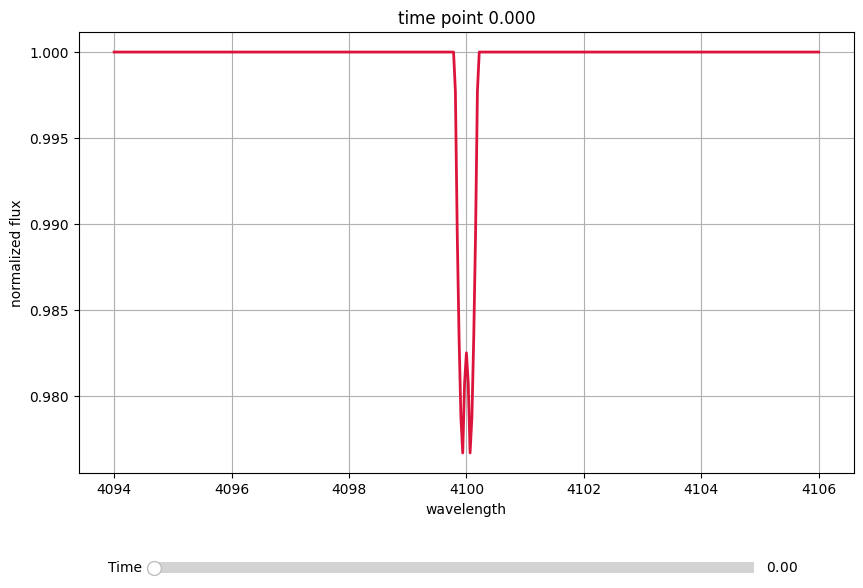

In [19]:
print(wavelength_df)
plot_pl.plot_slider(wavelength_df)

# Grayscale Test

Grayscale plot saved as 'grayscale'


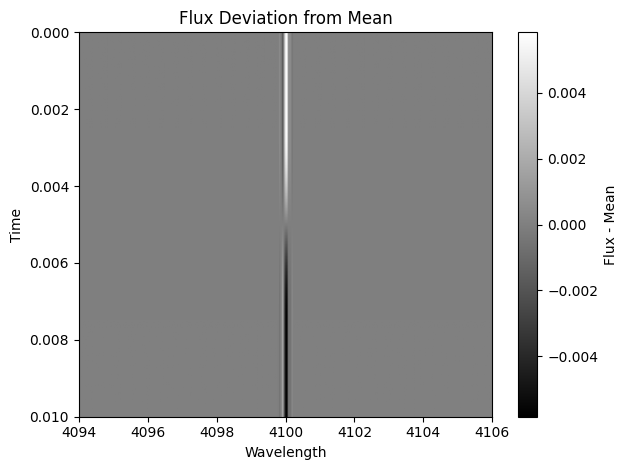

In [20]:
plot_pl.plot_grayscale(wavelength_df=wavelength_df)

Grayscale plot saved as 'grayscale'


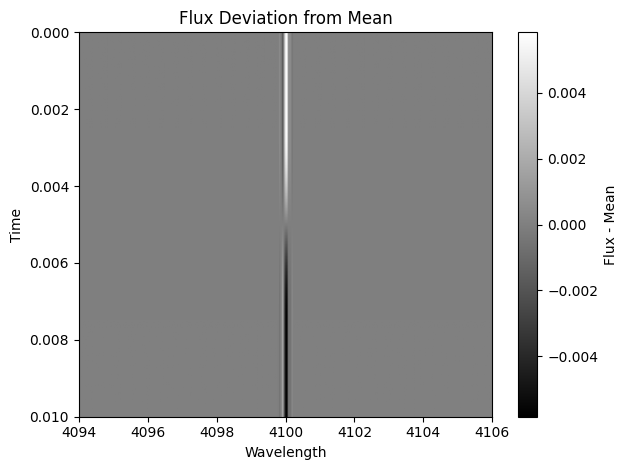

In [21]:
plot_pl.plot_grayscale(wavelength_df=wavelength_df)

In [22]:
print(plot_pl.extract_flux(wavelength_df=wavelength_df,time=0.01))

shape: (385, 3)
┌────────────┬─────────────────┬──────┐
│ wavelength ┆ normalized flux ┆ time │
│ ---        ┆ ---             ┆ ---  │
│ f64        ┆ f64             ┆ f64  │
╞════════════╪═════════════════╪══════╡
│ 4094.0     ┆ 1.0             ┆ 0.01 │
│ 4094.03125 ┆ 1.0             ┆ 0.01 │
│ 4094.0625  ┆ 1.0             ┆ 0.01 │
│ 4094.09375 ┆ 1.0             ┆ 0.01 │
│ 4094.125   ┆ 1.0             ┆ 0.01 │
│ …          ┆ …               ┆ …    │
│ 4105.875   ┆ 1.0             ┆ 0.01 │
│ 4105.90625 ┆ 1.0             ┆ 0.01 │
│ 4105.9375  ┆ 1.0             ┆ 0.01 │
│ 4105.96875 ┆ 1.0             ┆ 0.01 │
│ 4106.0     ┆ 1.0             ┆ 0.01 │
└────────────┴─────────────────┴──────┘
